# Crypto Market Intelligence Platform

An end-to-end cryptocurrency market analytics project combining live API data, financial indicators, market sentiment, interactive visualizations, and automated rule-based commentary.

The project analyzes Bitcoin and Ethereum using historical market data, moving averages, returns, volatility, drawdowns, market dominance, and the Crypto Fear & Greed Index.

### Core capabilities

- Live data collection through the CoinGecko API
- Bitcoin and Ethereum historical analysis
- Moving-average and momentum signals
- Annualized rolling volatility
- Maximum drawdown analysis
- Global crypto market overview
- Fear & Greed sentiment interpretation
- Interactive Plotly charts
- Automated executive summary and market commentary

The accompanying Streamlit application provides an interactive version of this analytical workflow.

## 1. Project Overview

The objective of this project is to transform raw cryptocurrency market data into a structured market-intelligence framework.

The analysis follows four stages:

1. Retrieve market data from external APIs.
2. Clean and transform the data into financial time series.
3. Calculate risk, return, momentum, and trend indicators.
4. Present the results through interactive charts and automated commentary.

## 2. Import Libraries

In [ ]:
import os
import time

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import userdata

COINGECKO_API_KEY = userdata.get("COINGECKO_API_KEY")

if not COINGECKO_API_KEY:
    raise ValueError(
        "CoinGecko API key not found. "
        "Add COINGECKO_API_KEY in the Colab Secrets panel."
    )

BASE_URL = "https://api.coingecko.com/api/v3"

HEADERS = {
    "x-cg-demo-api-key": COINGECKO_API_KEY
}

print("CoinGecko API key loaded successfully.")

CoinGecko API key loaded successfully.


## 3. API Configuration

In [ ]:
COINGECKO_API_KEY = userdata.get("COINGECKO_API_KEY")

HEADERS = {
    "accept": "application/json",
    "x-cg-demo-api-key": COINGECKO_API_KEY,
}

COINGECKO_BASE_URL = "https://api.coingecko.com/api/v3"
FEAR_GREED_URL = "https://api.alternative.me/fng/"

In [ ]:
def get_json(
    url: str,
    params: dict | None = None,
    headers: dict | None = None,
    timeout: int = 30,
) -> dict | list:
    """Request JSON data and return a clear error if the request fails."""

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=timeout,
        )

        response.raise_for_status()
        return response.json()

    except requests.exceptions.Timeout as exc:
        raise RuntimeError(f"Request timed out: {url}") from exc

    except requests.exceptions.HTTPError as exc:
        raise RuntimeError(
            f"HTTP error {response.status_code}: "
            f"{response.text[:300]}"
        ) from exc

    except requests.exceptions.RequestException as exc:
        raise RuntimeError(f"API request failed: {exc}") from exc

In [ ]:
asset_ids = ["bitcoin", "ethereum"]

current_market_data = get_json(
    f"{BASE_URL}/coins/markets",
    params={
        "vs_currency": "usd",
        "ids": ",".join(asset_ids),
        "order": "market_cap_desc",
        "sparkline": "false",
        "price_change_percentage": "24h,7d,30d",
    },
    headers=HEADERS,
)

current_market_df = pd.DataFrame(current_market_data)

current_market_df[
    [
        "name",
        "symbol",
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h",
        "price_change_percentage_7d_in_currency",
        "price_change_percentage_30d_in_currency",
        "last_updated",
    ]
]

,name,symbol,current_price,market_cap,total_volume,price_change_percentage_24h,price_change_percentage_7d_in_currency,price_change_percentage_30d_in_currency,last_updated
0,Bitcoin,btc,"65,552.0000",1315035253365,16736263862,1.9605,2.2896,8.9422,2026-07-27T06:12:46.527Z
1,Ethereum,eth,"1,969.0700",237593709753,7897310635,4.7363,5.3748,24.8815,2026-07-27T06:12:46.041Z


## 4. Data Collection Functions

In [ ]:
def get_market_chart(coin_id, days=365):
    """
    Download historical market data for a cryptocurrency.
    Returns daily prices, market caps and trading volume.
    """

    data = get_json(
        f"{BASE_URL}/coins/{coin_id}/market_chart",
        params={
            "vs_currency": "usd",
            "days": days,
            "interval": "daily"
        },
        headers=HEADERS,
    )

    return data

In [ ]:
btc_history = get_market_chart("bitcoin", days=365)

## 5. Data Processing Functions

In [ ]:
def create_history_dataframe(history_data):
    """
    Convert CoinGecko market_chart data into a clean DataFrame.
    """

    prices = pd.DataFrame(
        history_data["prices"],
        columns=["timestamp", "price"]
    )

    market_caps = pd.DataFrame(
        history_data["market_caps"],
        columns=["timestamp", "market_cap"]
    )

    volumes = pd.DataFrame(
        history_data["total_volumes"],
        columns=["timestamp", "volume"]
    )

    # Merge all three tables
    df = prices.merge(market_caps, on="timestamp")
    df = df.merge(volumes, on="timestamp")

    # Convert timestamp
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms")

    # Reorder columns
    df = df[
        [
            "date",
            "price",
            "market_cap",
            "volume"
        ]
    ]

    return df

In [ ]:
btc_history = get_market_chart(coin_id="bitcoin", days=365)
btc_df = create_history_dataframe(btc_history)
btc_df.head()

,date,price,market_cap,volume
0,2025-07-28,"119,446.7976","2,376,702,715,279.3086","30,308,457,320.2723"
1,2025-07-29,"118,009.1681","2,348,029,745,735.7812","43,515,454,619.4986"
2,2025-07-30,"117,830.5960","2,345,386,802,061.0337","42,510,545,896.9718"
3,2025-07-31,"117,827.8042","2,344,756,228,917.8003","41,209,699,028.4467"
4,2025-08-01,"115,744.9915","2,303,021,271,519.3223","45,165,574,220.9794"


## 6. Build BTC & ETH Dataset

In [ ]:
btc_df["daily_return"] = btc_df["price"].pct_change()

btc_df["7d_return"] = btc_df["price"].pct_change(7)

btc_df["30d_return"] = btc_df["price"].pct_change(30)

btc_df["30d_ma"] = btc_df["price"].rolling(window=30).mean()

btc_df["90d_ma"] = btc_df["price"].rolling(window=90).mean()

btc_df["30d_volatility"] = (
    btc_df["daily_return"]
    .rolling(window=30)
    .std()
    * (365 ** 0.5)
)

In [ ]:
# Keep only the latest observation for each date
btc_df["date"] = btc_df["date"].dt.date
btc_df = btc_df.drop_duplicates(subset="date", keep="last")

# Reset the index
btc_df = btc_df.reset_index(drop=True)

print(f"Number of observations: {len(btc_df)}")

Number of observations: 365


In [ ]:
def create_history_dataframe(history_data):
    """
    Convert raw CoinGecko market-chart data into a clean DataFrame.

    Parameters
    ----------
    history_data : dict
        Raw API response containing prices, market caps, and volumes.

    Returns
    -------
    pandas.DataFrame
        Clean daily cryptocurrency market data.
    """

    prices = pd.DataFrame(
        history_data["prices"],
        columns=["timestamp", "price"],
    )

    market_caps = pd.DataFrame(
        history_data["market_caps"],
        columns=["timestamp", "market_cap"],
    )

    volumes = pd.DataFrame(
        history_data["total_volumes"],
        columns=["timestamp", "volume"],
    )

    # Combine the three tables using their shared timestamp.
    df = prices.merge(market_caps, on="timestamp")
    df = df.merge(volumes, on="timestamp")

    # Convert CoinGecko's millisecond timestamp into a calendar date.
    df["date"] = pd.to_datetime(
        df["timestamp"],
        unit="ms",
        utc=True,
    ).dt.date

    # Keep the latest observation when the current date appears twice.
    df = df.drop_duplicates(
        subset="date",
        keep="last",
    )

    # Keep only the columns needed for the analysis.
    df = df[
        [
            "date",
            "price",
            "market_cap",
            "volume",
        ]
    ]

    # Sort chronologically and create a clean row index.
    df = df.sort_values("date").reset_index(drop=True)

    return df

In [ ]:
def add_financial_metrics(df):
    """
    Add return, trend, and volatility metrics to a market DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        Clean cryptocurrency market data.

    Returns
    -------
    pandas.DataFrame
        A copy of the data containing additional financial metrics.
    """

    # Create a copy so the original table is not changed accidentally.
    result = df.copy()

    # Percentage price changes.
    result["daily_return"] = result["price"].pct_change()
    result["7d_return"] = result["price"].pct_change(periods=7)
    result["30d_return"] = result["price"].pct_change(periods=30)

    # Rolling trend indicators.
    result["30d_ma"] = result["price"].rolling(window=30).mean()
    result["90d_ma"] = result["price"].rolling(window=90).mean()

    # Annualized volatility based on the latest 30 daily returns.
    result["30d_volatility"] = (
        result["daily_return"]
        .rolling(window=30)
        .std()
        * (365 ** 0.5)
    )

    return result

In [ ]:
def build_crypto_dataset(coin_id, days=365):
    """
    Download, clean, and analyze historical data for one cryptocurrency.

    Parameters
    ----------
    coin_id : str
        CoinGecko asset ID, such as 'bitcoin' or 'ethereum'.

    days : int
        Number of historical days to request.

    Returns
    -------
    pandas.DataFrame
        Clean market data with calculated financial metrics.
    """

    raw_history = get_market_chart(
        coin_id=coin_id,
        days=days,
    )

    clean_df = create_history_dataframe(raw_history)

    analyzed_df = add_financial_metrics(clean_df)

    return analyzed_df

In [ ]:
btc_df = build_crypto_dataset(
    coin_id="bitcoin",
    days=365,
)

btc_df.tail()

,date,price,market_cap,volume,daily_return,7d_return,30d_return,30d_ma,90d_ma,30d_volatility
360,2026-07-23,"66,077.0565","1,325,502,184,529.7004","28,939,202,566.3205",-0.0067,0.0210,0.0335,"62,786.8315","69,435.9086",0.3237
361,2026-07-24,"65,033.0221","1,304,584,533,794.3228","25,467,017,655.4989",-0.0158,0.0194,0.0378,"62,865.8558","69,297.9687",0.3206
362,2026-07-25,"64,099.0042","1,285,880,251,135.3728","26,959,674,488.7767",-0.0144,0.0030,0.0510,"62,969.5035","69,147.5741",0.3097
363,2026-07-26,"64,316.3642","1,290,267,626,178.7449","14,459,472,244.8486",0.0034,-0.0074,0.0768,"63,122.4911","68,988.4476",0.2989
364,2026-07-27,"65,555.0262","1,315,152,020,912.3721","16,964,237,614.4158",0.0193,0.0137,0.0922,"63,306.9144","68,857.2059",0.3045


In [ ]:
eth_df = build_crypto_dataset(
    coin_id="ethereum",
    days=365,
)

eth_df.tail()

,date,price,market_cap,volume,daily_return,7d_return,30d_return,30d_ma,90d_ma,30d_volatility
360,2026-07-23,"1,933.4133","233,329,678,635.4023","10,248,156,689.0264",0.0025,0.0087,0.1207,"1,753.5387","1,940.3384",0.4606
361,2026-07-24,"1,876.9500","226,515,488,311.5855","9,245,139,007.3643",-0.0292,0.0075,0.1268,"1,760.5799","1,935.4634",0.4554
362,2026-07-25,"1,861.2642","224,622,407,680.9319","8,602,589,038.6694",-0.0084,0.0111,0.1485,"1,768.6006","1,930.3600",0.4437
363,2026-07-26,"1,874.0317","226,163,180,101.4698","4,513,613,793.8375",0.0069,0.0063,0.1967,"1,778.8680","1,924.8586",0.4213
364,2026-07-27,"1,969.4171","237,674,452,360.0629","7,901,793,930.5628",0.0509,0.0527,0.2489,"1,791.9513","1,921.1423",0.4492


In [ ]:
def plot_price_with_moving_averages(
    df,
    asset_name,
):
    """
    Plot the asset price together with its
    30-day and 90-day moving averages.
    """

    plt.figure(figsize=(14, 7))

    plt.plot(
        df["date"],
        df["price"],
        label=f"{asset_name} Price",
        linewidth=2,
    )

    plt.plot(
        df["date"],
        df["30d_ma"],
        label="30-Day MA",
        linewidth=2,
    )

    plt.plot(
        df["date"],
        df["90d_ma"],
        label="90-Day MA",
        linewidth=2,
    )

    plt.title(f"{asset_name} Price Trend")

    plt.xlabel("Date")
    plt.ylabel("Price (USD)")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.show()

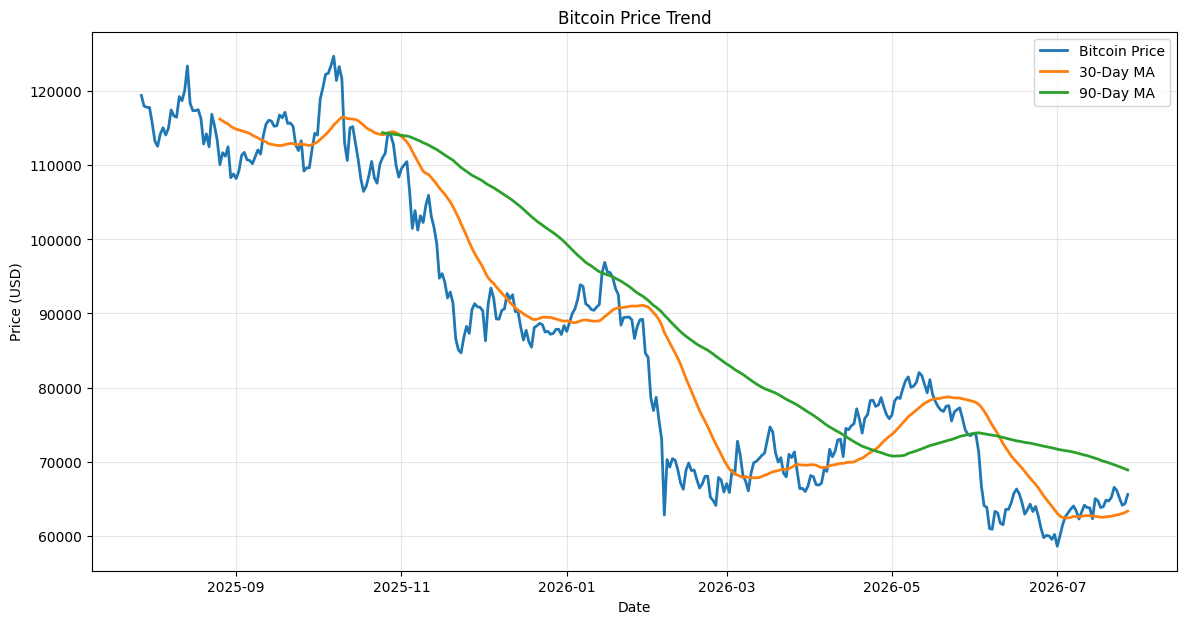

In [ ]:
plot_price_with_moving_averages(
    btc_df,
    "Bitcoin",
)

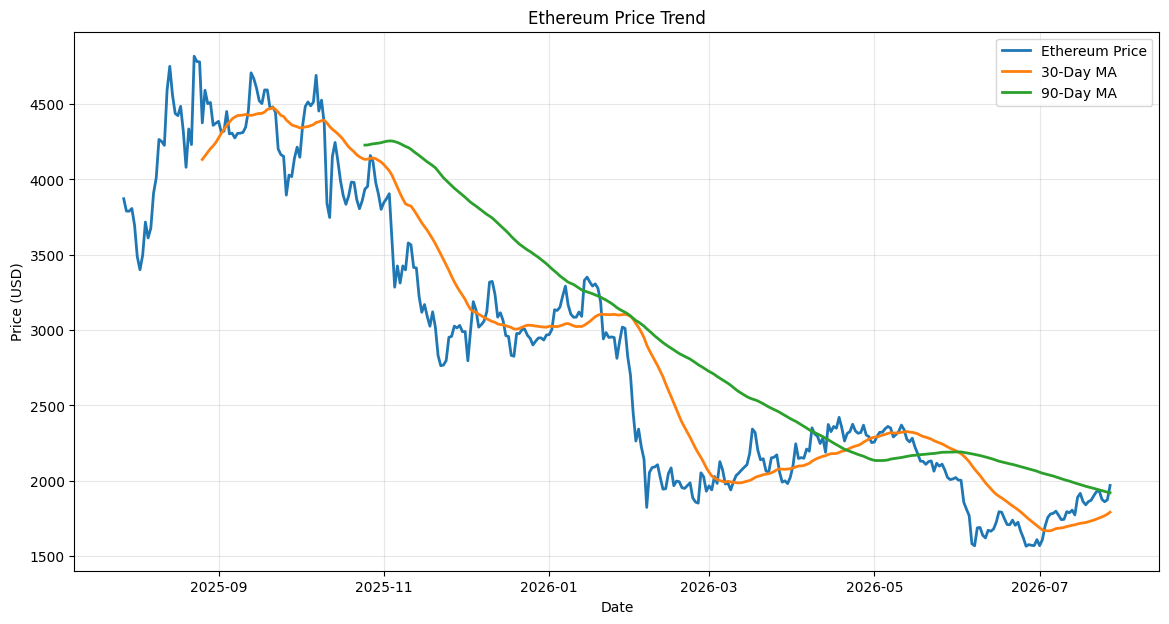

In [ ]:
plot_price_with_moving_averages(
    eth_df,
    "Ethereum",
)

# 7. Market Overview

This section retrieves live cryptocurrency market statistics from the CoinGecko API, including total market capitalization, Bitcoin dominance, and other high-level market indicators.

In [ ]:
def get_global_market_data():
    """
    Retrieve global cryptocurrency market statistics
    from the CoinGecko API.
    """

    url = "https://api.coingecko.com/api/v3/global"

    response = requests.get(
        url,
        headers=HEADERS,
    )

    response.raise_for_status()

    return response.json()["data"]

In [ ]:
global_data = get_global_market_data()

global_data.keys()

dict_keys(['active_cryptocurrencies', 'upcoming_icos', 'ongoing_icos', 'ended_icos', 'markets', 'total_market_cap', 'total_volume', 'market_cap_percentage', 'market_cap_change_percentage_24h_usd', 'volume_change_percentage_24h_usd', 'updated_at'])

In [ ]:
from pprint import pprint

In [ ]:
total_market_cap = global_data["total_market_cap"]["usd"]
total_volume = global_data["total_volume"]["usd"]

btc_dominance = global_data["market_cap_percentage"]["btc"]
eth_dominance = global_data["market_cap_percentage"]["eth"]

market_cap_change_24h = global_data[
    "market_cap_change_percentage_24h_usd"
]

In [ ]:
market_overview = pd.DataFrame({
    "Metric": [
        "Total Crypto Market Cap",
        "24h Trading Volume",
        "Bitcoin Dominance",
        "Ethereum Dominance",
        "24h Market Cap Change",
    ],
    "Value": [
        f"${total_market_cap / 1e12:.2f}T",
        f"${total_volume / 1e9:.2f}B",
        f"{btc_dominance:.2f}%",
        f"{eth_dominance:.2f}%",
        f"{market_cap_change_24h:.2f}%",
    ],
})

market_overview

,Metric,Value
0,Total Crypto Market Cap,$2.32T
1,24h Trading Volume,$45.86B
2,Bitcoin Dominance,56.45%
3,Ethereum Dominance,10.19%
4,24h Market Cap Change,1.60%


## 8. Market Sentiment

This section retrieves the Crypto Fear & Greed Index, a sentiment indicator that measures whether the market is driven primarily by fear or greed.

In [ ]:
def get_fear_and_greed():
    """
    Retrieve the latest Crypto Fear & Greed Index.
    """

    url = "https://api.alternative.me/fng/"

    response = requests.get(url)

    response.raise_for_status()

    return response.json()["data"][0]

In [ ]:
fear_greed = get_fear_and_greed()

fear_greed

{'value': '30',
 'value_classification': 'Fear',
 'timestamp': '1785110400',
 'time_until_update': '64031'}

In [ ]:
fear_greed_value = int(fear_greed["value"])
fear_greed_label = fear_greed["value_classification"]

In [ ]:
def get_sentiment_indicator(sentiment_label):
    """
    Return an emoji indicator for the Fear & Greed classification.
    """

    indicators = {
        "Extreme Fear": "🔴",
        "Fear": "🟠",
        "Neutral": "🟡",
        "Greed": "🟢",
        "Extreme Greed": "🟢",
    }

    return indicators.get(sentiment_label, "⚪")

In [ ]:
sentiment_icon = get_sentiment_indicator(fear_greed_label)

print(
    f"Market Sentiment: "
    f"{sentiment_icon} {fear_greed_label}"
)

Market Sentiment: 🟠 Fear


In [ ]:
def interpret_fear_greed(score):
    if score <= 25:
        return "Extreme fear suggests investors may be overly pessimistic."
    elif score <= 45:
        return "Market participants remain cautious."
    elif score <= 55:
        return "Market sentiment is balanced."
    elif score <= 75:
        return "Investors are becoming increasingly optimistic."
    else:
        return "Extreme optimism may indicate excessive market speculation."

## 9. Technical Signals

In [ ]:
def get_trend_signal(df):
    """
    Classify an asset's trend using price and moving averages.
    """

    latest = df.iloc[-1]

    price = latest["price"]
    ma_30 = latest["30d_ma"]
    ma_90 = latest["90d_ma"]

    if price > ma_30 and ma_30 > ma_90:
        return "🟢 Bullish"

    elif price < ma_30 and ma_30 < ma_90:
        return "🔴 Bearish"

    else:
        return "🟡 Mixed"

In [ ]:
def get_momentum_signal(df):
    """
    Classify short-term momentum using 7-day and 30-day returns.
    """

    latest = df.iloc[-1]

    return_7d = latest["7d_return"]
    return_30d = latest["30d_return"]

    if return_7d > 0 and return_30d > 0:
        return "🟢 Positive"

    elif return_7d < 0 and return_30d < 0:
        return "🔴 Negative"

    else:
        return "🟡 Mixed"

In [ ]:
def get_risk_signal(df):
    """
    Classify market risk using annualized 30-day volatility.
    """

    volatility = df.iloc[-1]["30d_volatility"]

    if volatility < 0.40:
        return "🟢 Low"

    elif volatility < 0.70:
        return "🟠 Medium"

    else:
        return "🔴 High"

In [ ]:
btc_trend = get_trend_signal(btc_df)
eth_trend = get_trend_signal(eth_df)

btc_momentum = get_momentum_signal(btc_df)
eth_momentum = get_momentum_signal(eth_df)

btc_risk = get_risk_signal(btc_df)
eth_risk = get_risk_signal(eth_df)

In [ ]:
import plotly.graph_objects as go

## 10. Interactive Charts

This section uses Plotly to create interactive visualizations with hover data, zoom controls, and selectable indicators.

In [ ]:
def plot_interactive_price_chart(df, asset_name):
    """
    Create an interactive price chart with
    30-day and 90-day moving averages.
    """

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["price"],
            mode="lines",
            name=f"{asset_name} Price",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "Price: $%{y:,.2f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["30d_ma"],
            mode="lines",
            name="30-Day Moving Average",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "30-Day MA: $%{y:,.2f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["90d_ma"],
            mode="lines",
            name="90-Day Moving Average",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "90-Day MA: $%{y:,.2f}"
                "<extra></extra>"
            ),
        )
    )

    fig.update_layout(
        title=f"{asset_name} Price and Moving Averages",
        xaxis_title="Date",
        yaxis_title="Price (USD)",
        hovermode="x unified",
        template="plotly_white",
        height=600,
        legend_title="Indicator",
    )

    fig.update_xaxes(
        rangeslider_visible=True,
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=3, label="3M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(label="All", step="all"),
            ]
        ),
    )

    fig.show()

In [ ]:
plot_interactive_price_chart(
    btc_df,
    "Bitcoin",
)

In [ ]:
plot_interactive_price_chart(
    eth_df,
    "Ethereum",
)

In [ ]:
def create_normalized_comparison(btc_df, eth_df):
    """
    Combine Bitcoin and Ethereum data and normalize
    both price series to a starting value of 100.
    """

    btc_prices = btc_df[
        ["date", "price"]
    ].copy()

    btc_prices = btc_prices.rename(
        columns={"price": "btc_price"}
    )

    eth_prices = eth_df[
        ["date", "price"]
    ].copy()

    eth_prices = eth_prices.rename(
        columns={"price": "eth_price"}
    )

    comparison_df = btc_prices.merge(
        eth_prices,
        on="date",
        how="inner",
    )

    comparison_df["btc_normalized"] = (
        comparison_df["btc_price"]
        / comparison_df["btc_price"].iloc[0]
        * 100
    )

    comparison_df["eth_normalized"] = (
        comparison_df["eth_price"]
        / comparison_df["eth_price"].iloc[0]
        * 100
    )

    return comparison_df

In [ ]:
comparison_df = create_normalized_comparison(
    btc_df,
    eth_df,
)

comparison_df.head()

,date,btc_price,eth_price,btc_normalized,eth_normalized
0,2025-07-28,"119,446.7976","3,871.9514",100.0000,100.0000
1,2025-07-29,"118,009.1681","3,790.1063",98.7964,97.8862
2,2025-07-30,"117,830.5960","3,789.3004",98.6469,97.8654
3,2025-07-31,"117,827.8042","3,807.3816",98.6446,98.3324
4,2025-08-01,"115,744.9915","3,696.5992",96.9009,95.4712


In [ ]:
def plot_normalized_performance(comparison_df):
    """
    Compare Bitcoin and Ethereum performance
    using normalized price indices.
    """

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=comparison_df["date"],
            y=comparison_df["btc_normalized"],
            mode="lines",
            name="Bitcoin",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "BTC Index: %{y:.2f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_trace(
        go.Scatter(
            x=comparison_df["date"],
            y=comparison_df["eth_normalized"],
            mode="lines",
            name="Ethereum",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "ETH Index: %{y:.2f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=100,
        line_dash="dash",
        annotation_text="Starting value",
    )

    fig.update_layout(
        title="Bitcoin vs Ethereum: Normalized Performance",
        xaxis_title="Date",
        yaxis_title="Indexed Performance",
        hovermode="x unified",
        template="plotly_white",
        height=600,
        legend_title="Asset",
    )

    fig.update_xaxes(
        rangeslider_visible=True,
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=3, label="3M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(label="All", step="all"),
            ]
        ),
    )

    fig.show()

In [ ]:
plot_normalized_performance(comparison_df)

In [ ]:
def plot_volatility_comparison(btc_df, eth_df):
    """
    Compare annualized rolling 30-day volatility
    for Bitcoin and Ethereum.
    """

    volatility_df = btc_df[
        ["date", "30d_volatility"]
    ].rename(
        columns={
            "30d_volatility": "btc_volatility"
        }
    )

    eth_volatility = eth_df[
        ["date", "30d_volatility"]
    ].rename(
        columns={
            "30d_volatility": "eth_volatility"
        }
    )

    volatility_df = volatility_df.merge(
        eth_volatility,
        on="date",
        how="inner",
    )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=volatility_df["date"],
            y=volatility_df["btc_volatility"] * 100,
            mode="lines",
            name="Bitcoin",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "BTC Volatility: %{y:.2f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.add_trace(
        go.Scatter(
            x=volatility_df["date"],
            y=volatility_df["eth_volatility"] * 100,
            mode="lines",
            name="Ethereum",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "ETH Volatility: %{y:.2f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.update_layout(
        title="Bitcoin vs Ethereum: Rolling 30-Day Volatility",
        xaxis_title="Date",
        yaxis_title="Annualized Volatility (%)",
        hovermode="x unified",
        template="plotly_white",
        height=600,
        legend_title="Asset",
    )

    fig.update_xaxes(
        rangeslider_visible=True
    )

    fig.show()

In [ ]:
plot_volatility_comparison(
    btc_df,
    eth_df,
)

## 11. Executive Summary

In [ ]:
def create_executive_summary(
    total_market_cap,
    btc_dominance,
    market_cap_change_24h,
    fear_greed_value,
    fear_greed_label,
    btc_trend,
    eth_trend,
):
    """
    Generate a concise market summary from the latest indicators.
    """

    if market_cap_change_24h > 0:
        market_direction = "increased"
    elif market_cap_change_24h < 0:
        market_direction = "declined"
    else:
        market_direction = "remained unchanged"

    summary = [
        (
            f"Total cryptocurrency market capitalization stands at "
            f"${total_market_cap / 1e12:.2f}T."
        ),
        (
            f"Bitcoin accounts for {btc_dominance:.2f}% of total "
            f"crypto market capitalization."
        ),
        (
            f"The overall market {market_direction} by "
            f"{abs(market_cap_change_24h):.2f}% over the last 24 hours."
        ),
        (
            f"The Fear & Greed Index is {fear_greed_value}/100, "
            f"indicating {fear_greed_label.lower()}."
        ),
        (
            f"Current technical conditions classify Bitcoin as "
            f"{btc_trend[2:]} and Ethereum as {eth_trend[2:]}."
        ),
    ]

    return summary

In [ ]:
def display_market_dashboard(
    market_overview,
    fear_greed_value,
    fear_greed_label,
    btc_df,
    eth_df,
    total_market_cap,
    btc_dominance,
    market_cap_change_24h,
):
    """
    Display a formatted crypto market intelligence dashboard.
    """

    sentiment_icon = get_sentiment_indicator(
        fear_greed_label
    )

    interpretation = interpret_fear_greed(
        fear_greed_value
    )

    btc_trend = get_trend_signal(btc_df)
    eth_trend = get_trend_signal(eth_df)

    btc_momentum = get_momentum_signal(btc_df)
    eth_momentum = get_momentum_signal(eth_df)

    btc_risk = get_risk_signal(btc_df)
    eth_risk = get_risk_signal(eth_df)

    executive_summary = create_executive_summary(
        total_market_cap=total_market_cap,
        btc_dominance=btc_dominance,
        market_cap_change_24h=market_cap_change_24h,
        fear_greed_value=fear_greed_value,
        fear_greed_label=fear_greed_label,
        btc_trend=btc_trend,
        eth_trend=eth_trend,
    )

    divider = "─" * 70

    print(divider)
    print("               CRYPTO MARKET INTELLIGENCE DASHBOARD")
    print(divider)

    print("\nMarket Overview\n")

    for _, row in market_overview.iterrows():
        print(f"{row['Metric']:<35}{row['Value']}")

    print("\nMarket Sentiment\n")

    print(
        f"{'Fear & Greed Index':<35}"
        f"{fear_greed_value}/100"
    )

    print(
        f"{'Current Sentiment':<35}"
        f"{sentiment_icon} {fear_greed_label}"
    )

    print("\nInterpretation\n")
    print(interpretation)

    print("\nMarket Signals\n")

    print(f"{'Bitcoin Trend':<35}{btc_trend}")
    print(f"{'Ethereum Trend':<35}{eth_trend}")

    print(f"{'Bitcoin Momentum':<35}{btc_momentum}")
    print(f"{'Ethereum Momentum':<35}{eth_momentum}")

    print(f"{'Bitcoin Risk':<35}{btc_risk}")
    print(f"{'Ethereum Risk':<35}{eth_risk}")

    print("\nExecutive Summary\n")

    for sentence in executive_summary:
        print(f"• {sentence}")

    print(divider)

In [ ]:
display_market_dashboard(
    market_overview=market_overview,
    fear_greed_value=fear_greed_value,
    fear_greed_label=fear_greed_label,
    btc_df=btc_df,
    eth_df=eth_df,
    total_market_cap=total_market_cap,
    btc_dominance=btc_dominance,
    market_cap_change_24h=market_cap_change_24h,
)

──────────────────────────────────────────────────────────────────────
               CRYPTO MARKET INTELLIGENCE DASHBOARD
──────────────────────────────────────────────────────────────────────

Market Overview

Total Crypto Market Cap            $2.32T
24h Trading Volume                 $45.86B
Bitcoin Dominance                  56.45%
Ethereum Dominance                 10.19%
24h Market Cap Change              1.60%

Market Sentiment

Fear & Greed Index                 30/100
Current Sentiment                  🟠 Fear

Interpretation

Market participants remain cautious.

Market Signals

Bitcoin Trend                      🟡 Mixed
Ethereum Trend                     🟡 Mixed
Bitcoin Momentum                   🟢 Positive
Ethereum Momentum                  🟢 Positive
Bitcoin Risk                       🟢 Low
Ethereum Risk                      🟠 Medium

Executive Summary

• Total cryptocurrency market capitalization stands at $2.32T.
• Bitcoin accounts for 56.45% of total crypto market capit

## 12. Automated Market Commentary

This section generates a rule-based market commentary using global market conditions, sentiment, trend, momentum, and volatility indicators.

In [ ]:
def create_market_commentary(
    total_market_cap,
    market_cap_change_24h,
    btc_dominance,
    fear_greed_value,
    fear_greed_label,
    btc_df,
    eth_df,
):
    """
    Generate professional rule-based crypto market commentary.
    """

    btc_latest = btc_df.iloc[-1]
    eth_latest = eth_df.iloc[-1]

    btc_trend = get_trend_signal(btc_df)
    eth_trend = get_trend_signal(eth_df)

    btc_momentum = get_momentum_signal(btc_df)
    eth_momentum = get_momentum_signal(eth_df)

    btc_risk = get_risk_signal(btc_df)
    eth_risk = get_risk_signal(eth_df)

    if market_cap_change_24h > 0:
        market_direction = (
            f"rose by {market_cap_change_24h:.2f}%"
        )
    elif market_cap_change_24h < 0:
        market_direction = (
            f"declined by {abs(market_cap_change_24h):.2f}%"
        )
    else:
        market_direction = "was broadly unchanged"

    if btc_dominance >= 60:
        dominance_comment = (
            "Bitcoin dominance remains elevated, suggesting "
            "capital is concentrated in the market's largest asset."
        )
    elif btc_dominance >= 50:
        dominance_comment = (
            "Bitcoin continues to represent more than half of total "
            "crypto market capitalization."
        )
    else:
        dominance_comment = (
            "Bitcoin dominance is below 50%, indicating relatively "
            "greater participation across alternative assets."
        )

    if fear_greed_value <= 25:
        sentiment_comment = (
            "Sentiment is in extreme fear territory, indicating "
            "significant risk aversion among market participants."
        )
    elif fear_greed_value <= 45:
        sentiment_comment = (
            "Sentiment remains cautious, with investors showing "
            "a preference for lower-risk positioning."
        )
    elif fear_greed_value <= 55:
        sentiment_comment = (
            "Sentiment is broadly neutral, suggesting no strong "
            "directional conviction."
        )
    elif fear_greed_value <= 75:
        sentiment_comment = (
            "Sentiment is optimistic, although positioning does not "
            "yet appear excessively speculative."
        )
    else:
        sentiment_comment = (
            "Sentiment is extremely optimistic, which may increase "
            "the risk of short-term overheating."
        )

    commentary = (
        f"The total cryptocurrency market is valued at approximately "
        f"${total_market_cap / 1e12:.2f}T and {market_direction} over "
        f"the past 24 hours. {dominance_comment} "
        f"The Fear & Greed Index stands at {fear_greed_value}/100 "
        f"and is classified as {fear_greed_label.lower()}. "
        f"{sentiment_comment} "
        f"Bitcoin currently shows a {btc_trend[2:].lower()} trend, "
        f"{btc_momentum[2:].lower()} momentum, and "
        f"{btc_risk[2:].lower()} volatility risk. "
        f"Ethereum shows a {eth_trend[2:].lower()} trend, "
        f"{eth_momentum[2:].lower()} momentum, and "
        f"{eth_risk[2:].lower()} volatility risk. "
        f"Bitcoin's latest 30-day return is "
        f"{btc_latest['30d_return'] * 100:.2f}%, compared with "
        f"{eth_latest['30d_return'] * 100:.2f}% for Ethereum."
    )

    return commentary

In [ ]:
market_commentary = create_market_commentary(
    total_market_cap=total_market_cap,
    market_cap_change_24h=market_cap_change_24h,
    btc_dominance=btc_dominance,
    fear_greed_value=fear_greed_value,
    fear_greed_label=fear_greed_label,
    btc_df=btc_df,
    eth_df=eth_df,
)

print("MARKET COMMENTARY\n")
print(market_commentary)

MARKET COMMENTARY

The total cryptocurrency market is valued at approximately $2.32T and rose by 1.60% over the past 24 hours. Bitcoin continues to represent more than half of total crypto market capitalization. The Fear & Greed Index stands at 30/100 and is classified as fear. Sentiment remains cautious, with investors showing a preference for lower-risk positioning. Bitcoin currently shows a mixed trend, positive momentum, and low volatility risk. Ethereum shows a mixed trend, positive momentum, and medium volatility risk. Bitcoin's latest 30-day return is 9.22%, compared with 24.89% for Ethereum.


## 13. Key Findings

- Bitcoin and Ethereum displayed materially different risk and drawdown profiles over the selected period.
- Ethereum experienced greater maximum drawdown and generally higher rolling volatility.
- Bitcoin remained the dominant cryptocurrency by market capitalization.
- Market sentiment and technical signals did not always move in the same direction, demonstrating the importance of combining multiple indicators.
- Normalized performance provides a more meaningful cross-asset comparison than comparing raw prices.

## 14. Limitations and Future Development

### Limitations

- The analysis is based primarily on historical price data.
- Signal thresholds are transparent, rule-based assumptions rather than predictive models.
- API availability and rate limits may affect data retrieval.
- The Fear & Greed Index summarizes broad market sentiment and should not be treated as an investment signal on its own.

### Future development

- Sharpe and Sortino ratios
- Rolling BTC–ETH correlation
- Value at Risk
- Additional cryptocurrencies
- User-selectable assets and periods
- Automated deployment through Streamlit Community Cloud
- Optional generative-AI market commentary

This project is intended for educational and portfolio purposes and does not constitute investment advice.